<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week4_Assignment/Machaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install Dependencies**

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Define Document

In [ ]:
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

Text Preprocessing

In [ ]:
sent_token = sent_tokenize(sentence)
print(sent_token)

['\nManchester City makes history by winning Club World Cup\n\nManchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.', 'Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.', 'The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.', '“We’ve shown over the past 12 months we are the best team in the world.', 'Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.', '“To win these five trophies – for me, the five biggest prizes available to us – is incredible.', 'I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.', 'I cou

Tokenized sentences:
Manchester City makes history by winning Club World Cup
Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t a

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Word,TF-IDF Score
history,0.4001
winning,0.4001
makes,0.4001
by,0.3502
cup,0.3148
world,0.3148
manchester,0.2873
club,0.2649
city,0.2150


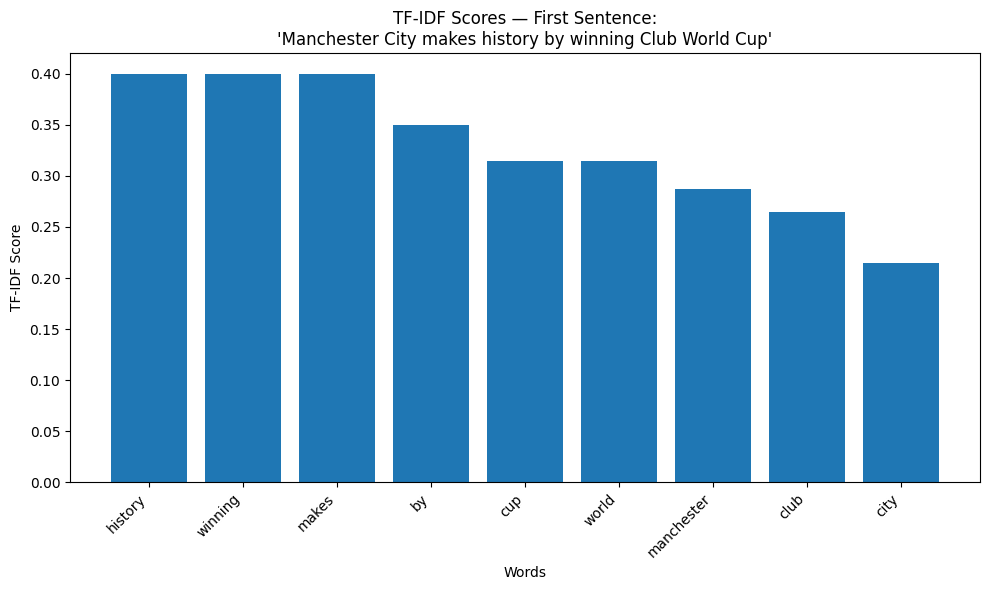

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

nltk.download('punkt')
nltk.download('stopwords')


lines = [line.strip() for line in sentence.split('\n') if line.strip()]

print("Tokenized sentences:")
for line in lines:
    print(line)

clean_sentences = lines
print("\nCleaned sentences:")
for sent in clean_sentences:
    print(sent)

# fit TF-IDF
tfidf_model = TfidfVectorizer()
tfidf_matrix = tfidf_model.fit_transform(clean_sentences)

print("\nTF-IDF Matrix (sparse):")
print(tfidf_matrix)

print("\nMatrix shape (sentences x unique words):")
print(tfidf_matrix.shape)

vocabulary = tfidf_model.get_feature_names_out()
print("\nVocabulary:")
print(vocabulary)

first_row = tfidf_matrix[0].toarray()
print("\nTF-IDF values for the first sentence:")
print(first_row)

def get_tfidf_scores(matrix, idx, vocab):
    """Returns a sorted DataFrame of TF-IDF scores for a given sentence index."""
    scores = matrix[idx].toarray().flatten()
    df = pd.DataFrame({'Word': vocab, 'TF-IDF Score': scores})
    df = df[df['TF-IDF Score'] > 0].sort_values(by='TF-IDF Score', ascending=False)
    return df

first_sentence_scores = get_tfidf_scores(tfidf_matrix, 0, vocabulary)
print("\nTF-IDF scores for the first sentence (sorted):")

display(
    first_sentence_scores.style
    .background_gradient(subset=['TF-IDF Score'], cmap='Blues')
    .format({'TF-IDF Score': '{:.4f}'})
    .set_caption("TF-IDF Scores — First Sentence")
    .hide(axis='index')
)

# bar chart visualization
first_sentence_text = clean_sentences[0]

plt.figure(figsize=(10, 6))
plt.bar(first_sentence_scores['Word'], first_sentence_scores['TF-IDF Score'])
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title(f"TF-IDF Scores — First Sentence:\n'{first_sentence_text}'")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sentence scores:
  Sentence 1: 0.3275
  Sentence 2: 0.2135
  Sentence 3: 0.1714
  Sentence 4: 0.2195
  Sentence 5: 0.1634
  Sentence 6: 0.1591
  Sentence 7: 0.2769
  Sentence 8: 0.1580
  Sentence 9: 0.1880
  Sentence 10: 0.2463
  Sentence 11: 0.2269
  Sentence 12: 0.2419
  Sentence 13: 0.1481
  Sentence 14: 0.1883
  Sentence 15: 0.2179
  Sentence 16: 0.1831
  Sentence 17: 0.2530
  Sentence 18: 0.2428


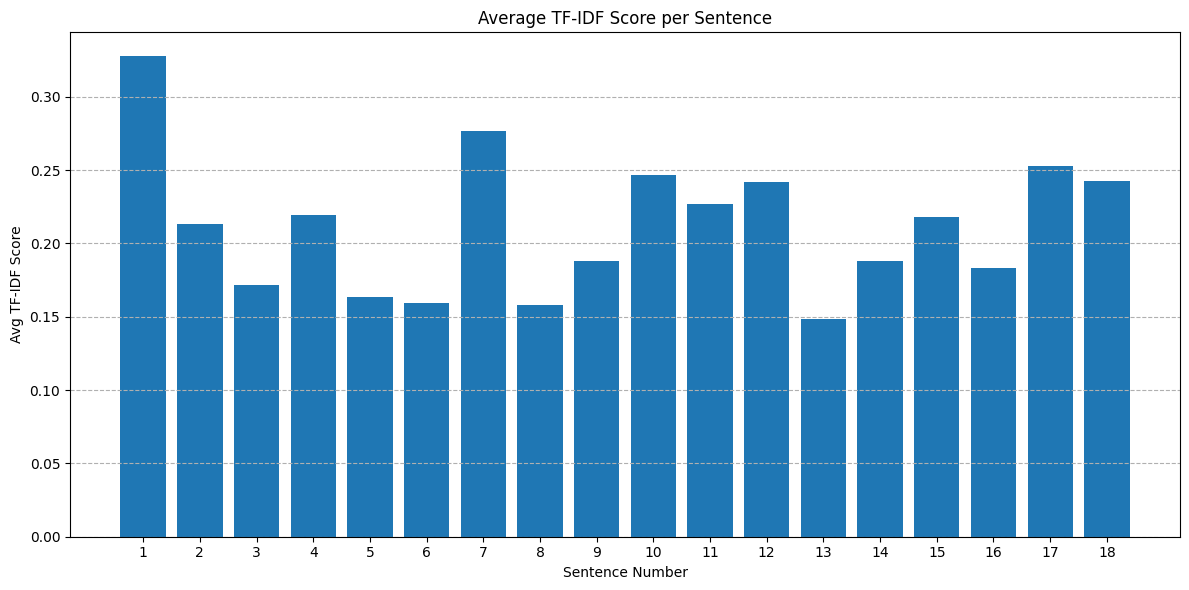

In [ ]:
scores = []

for row in tfidf_matrix:
    total = row.sum()
    n_words = len(row.data)
    avg = total / n_words if n_words > 0 else 0
    scores.append(avg)

print("Sentence scores:")
for i, score in enumerate(scores):
    print(f"  Sentence {i+1}: {score:.4f}")

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(scores) + 1), scores)
plt.xlabel("Sentence Number")
plt.ylabel("Avg TF-IDF Score")
plt.title("Average TF-IDF Score per Sentence")
plt.xticks(range(1, len(scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

Define thresold

In [ ]:
threshold = sum(scores) / len(scores)
print("Threshold:", round(threshold, 4))

Threshold: 0.2125


In [ ]:
summary = []

for i, score in enumerate(scores):
    if score >= threshold:
        summary.append(clean_sentences[i])

print("Summary sentences:")
for sent in summary:
    print(f"- {sent}")

print("\nFinal summary:")
print(" ".join(summary))

Summary sentences:
- Manchester City makes history by winning Club World Cup
- Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
- The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
- It took just 40 seconds for Manchester City to take the lead.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.
- City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
- “It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”
- The champion heads back to England where it faces a tough title defence in the Premier League.